# Combined Analysis

*Per-suspect heart rate analysis combining HR traces, mean HR per session, and average HR rise/drop rates.*

In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from datetime import datetime


# Week colour palettes: light -> dark progression within each week
WEEK_PALETTES = {
    1: ["#c6dbef", "#6baed6", "#2171b5"],  # blues
    2: ["#c7e9c0", "#74c476", "#238b45"],  # greens
    3: ["#fcbba1", "#fb6a4a", "#cb181d"],  # reds
}

# Hatch settings
RUN_HATCH   = "////"
WALK_HATCH  = "\\\\\\\\"
HATCH_COLOR = "#aaaaaa"

# Protocol definition
RUN_DURATIONS  = [70, 80, 90, 100, 110, 120]  # seconds per run interval
WALK_DURATION  = 60                             # seconds per walk recovery
PROTOCOL_DURATION_SEC = sum(RUN_DURATIONS) + WALK_DURATION * len(RUN_DURATIONS)  # 930s

# 6-colour palette for distinguishing individual run intervals (ColorBrewer Dark2)
INTERVAL_COLORS = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02"]
INTERVAL_LABELS = [f"Interval {i+1} ({d}s run)" for i, d in enumerate(RUN_DURATIONS)]


def get_session_colors(n_sessions: int) -> list:
    colors = []
    for i in range(n_sessions):
        week = min(i // 3 + 1, 3)
        pos_in_week = i % 3
        colors.append(WEEK_PALETTES[week][pos_in_week])
    return colors


def build_interval_schedule(run_start_sec: float) -> list:
    schedule, cursor = [], run_start_sec
    for run_dur in RUN_DURATIONS:
        schedule.append({"start": cursor, "end": cursor + run_dur, "phase": "run"})
        cursor += run_dur
        schedule.append({"start": cursor, "end": cursor + WALK_DURATION, "phase": "walk"})
        cursor += WALK_DURATION
    return schedule


def parse_run_data(records: list):
    """Parse per_second_data into elapsed-time and HR numpy arrays."""
    if not records:
        return np.array([]), np.array([])
    t0_abs = datetime.fromisoformat(records[0]["timestamp"])
    times, hrs = [], []
    for rec in records:
        t_abs = datetime.fromisoformat(rec["timestamp"])
        times.append((t_abs - t0_abs).total_seconds())
        hrs.append(rec["heart_rate"])
    return np.array(times), np.array(hrs)


def extract_hrr_per_interval(
    records: list,
    schedule: list,
    interval_range: tuple = (1, 6),
    window_sec: int = 10,
) -> list:
    """
    For each run->walk transition in interval_range (1-based, inclusive):
      - peak HR: maximum HR in [run_end - window_sec, run_end + window_sec]
      - recovery HR:
          intervals 1-5: minimum HR in [run_end + 60 - window_sec, run_end + 60 + window_sec]
          interval 6:    single closest point to run_end + 60
      - HRR: peak - recovery
    Returns a list of dicts, one per included interval.
    """
    if not records:
        return []

    t0_abs = datetime.fromisoformat(records[0]["timestamp"])
    times, hrs = [], []
    for rec in records:
        t_abs = datetime.fromisoformat(rec["timestamp"])
        times.append((t_abs - t0_abs).total_seconds())
        hrs.append(rec["heart_rate"])

    times = np.array(times)
    hrs   = np.array(hrs)

    all_run_segs  = [s for s in schedule if s["phase"] == "run"]
    all_walk_segs = [s for s in schedule if s["phase"] == "walk"]
    total_intervals = len(all_run_segs)

    i_start = interval_range[0] - 1
    i_end   = interval_range[1]
    run_segs  = all_run_segs[i_start:i_end]
    walk_segs = all_walk_segs[i_start:i_end]

    results = []
    for interval_num, (run_seg, walk_seg) in enumerate(zip(run_segs, walk_segs), start=interval_range[0]):
        peak_mask = (
            (times >= run_seg["end"] - window_sec) &
            (times <= run_seg["end"] + window_sec)
        )
        if not np.any(peak_mask):
            results.append(None)
            continue
        peak_idx  = np.argmax(hrs[peak_mask])
        peak_hr   = hrs[peak_mask][peak_idx]
        peak_time = times[peak_mask][peak_idx]

        target_time = run_seg["end"] + 60
        is_last     = (interval_num == total_intervals)

        if is_last:
            rec_idx  = np.argmin(np.abs(times - target_time))
            rec_hr   = hrs[rec_idx]
            rec_time = times[rec_idx]
        else:
            rec_mask = (
                (times >= target_time - window_sec) &
                (times <= target_time + window_sec)
            )
            if not np.any(rec_mask):
                rec_idx  = np.argmin(np.abs(times - target_time))
                rec_hr   = hrs[rec_idx]
                rec_time = times[rec_idx]
            else:
                rec_idx  = np.argmin(hrs[rec_mask])
                rec_hr   = hrs[rec_mask][rec_idx]
                rec_time = times[rec_mask][rec_idx]

        hrr = float(peak_hr) - float(rec_hr)
        results.append({
            "interval":      interval_num,
            "peak_hr":       float(peak_hr),
            "peak_time":     float(peak_time),
            "recovery_hr":   float(rec_hr),
            "recovery_time": float(rec_time),
            "hrr":           hrr,
        })

    return results


def load_suspect(json_path: str) -> tuple:
    """Load suspect data, return (suspect_id, runs)."""
    with open(json_path, "r") as f:
        data = json.load(f)
    return data["suspect_id"], data["runs"]


def _add_session_xticks(ax, n_runs: int):
    ax.set_xticks(range(1, n_runs + 1))
    ax.set_xticklabels([
        f"S{i}\n(W{((i-1)//3)+1})" for i in range(1, n_runs + 1)
    ], fontsize=8)


def _draw_grid(ax):
    ax.set_axisbelow(True)
    ax.grid(axis="both", color="grey", linestyle="--", linewidth=0.5, alpha=0.4)


def _edge_hr(times, hrs, target, edge_window_sec, seg_start, seg_end):
    """
    Get HR estimate near a segment boundary, adapting to data granularity.
    First tries a fixed time window; if empty, falls back to the nearest
    sample within the segment bounds.
    """
    if target == seg_start:
        mask = (times >= seg_start) & (times <= seg_start + edge_window_sec)
    else:
        mask = (times >= seg_end - edge_window_sec) & (times <= seg_end)
    if np.any(mask):
        return float(np.mean(hrs[mask]))
    # Fallback: nearest sample within segment
    seg_mask = (times >= seg_start) & (times <= seg_end)
    if not np.any(seg_mask):
        return None
    seg_times = times[seg_mask]
    seg_hrs = hrs[seg_mask]
    nearest_idx = np.argmin(np.abs(seg_times - target))
    return float(seg_hrs[nearest_idx])

def compute_hr_rise_rate(
    runs: list,
    run_start_sec: float,
    edge_window_sec: int = 5,
) -> dict:
    """
    For each of 6 run intervals, compute rate of HR increase.
    rise_rate = (hr_end - hr_start) / (duration_sec / 60)  in bpm/min.
    Returns {interval_num (1-6): [rise_rate_per_session]}.
    """
    schedule = build_interval_schedule(run_start_sec)
    run_segs = [s for s in schedule if s["phase"] == "run"]

    result = {i + 1: [] for i in range(len(run_segs))}

    for run in runs:
        times, hrs = parse_run_data(run["per_second_data"])
        if len(times) == 0:
            for k in result:
                result[k].append(None)
            continue

        for i, seg in enumerate(run_segs):
            duration_sec = seg["end"] - seg["start"]

            hr_start = _edge_hr(times, hrs, seg["start"], edge_window_sec, seg["start"], seg["end"])
            hr_end = _edge_hr(times, hrs, seg["end"], edge_window_sec, seg["start"], seg["end"])

            if hr_start is not None and hr_end is not None:
                rise_rate = (hr_end - hr_start) / (duration_sec / 60)
                result[i + 1].append(float(rise_rate))
            else:
                result[i + 1].append(None)

    return result


def compute_hr_drop_rate(
    runs: list,
    run_start_sec: float,
    edge_window_sec: int = 5,
) -> dict:
    """
    For each of 6 walk intervals, compute rate of HR decrease.
    drop_rate = (hr_start - hr_end) / (duration_sec / 60)  in bpm/min.
    Positive = HR decreasing (recovery). Negative = HR still rising.
    Returns {interval_num (1-6): [drop_rate_per_session]}.
    """
    schedule = build_interval_schedule(run_start_sec)
    walk_segs = [s for s in schedule if s["phase"] == "walk"]

    result = {i + 1: [] for i in range(len(walk_segs))}

    for run in runs:
        times, hrs = parse_run_data(run["per_second_data"])
        if len(times) == 0:
            for k in result:
                result[k].append(None)
            continue

        for i, seg in enumerate(walk_segs):
            duration_sec = seg["end"] - seg["start"]

            hr_start = _edge_hr(times, hrs, seg["start"], edge_window_sec, seg["start"], seg["end"])
            hr_end = _edge_hr(times, hrs, seg["end"], edge_window_sec, seg["start"], seg["end"])

            if hr_start is not None and hr_end is not None:
                drop_rate = (hr_start - hr_end) / (duration_sec / 60)
                result[i + 1].append(float(drop_rate))
            else:
                result[i + 1].append(None)

    return result

**Plot 1: HR trace across all sessions overlaid**

In [2]:
def plot_hr_all_sessions(
    json_path: str,
    run_start_sec: float,
    time_unit: str = "seconds",
    figsize: tuple = (14, 6),
    alpha_traces: float = 0.9,
    title: str = None,
):
    """
    Plot all HR sessions for one participant overlaid on a single axis.
    Run/walk intervals are distinguished by hatch patterns (no fill colour).
    Sessions are coloured light-to-dark within each week (week 1=blue, 2=green, 3=red).
    Legend is placed horizontally below the plot.

    Parameters
    ----------
    json_path      : path to suspect_#.json
    run_start_sec  : elapsed seconds from session start at which the first run interval begins
    time_unit      : "seconds" or "minutes" for the x-axis label
    figsize        : figure size tuple (slightly taller to accommodate bottom legend)
    alpha_traces   : transparency of individual session lines
    title          : optional plot title override
    """
    # ------------------------------------------------------------------ load
    with open(json_path, "r") as f:
        data = json.load(f)

    suspect_id = data["suspect_id"]
    runs = data["runs"]

    # --------------------------------------------------------- interval bands
    schedule = build_interval_schedule(run_start_sec)
    protocol_end_sec = run_start_sec + PROTOCOL_DURATION_SEC

    # ------------------------------------------------------------------ plot
    fig, ax = plt.subplots(figsize=figsize)

    # Background hatch bands
    for interval in schedule:
        t0 = interval["start"] / 60 if time_unit == "minutes" else interval["start"]
        t1 = interval["end"]   / 60 if time_unit == "minutes" else interval["end"]
        hatch = RUN_HATCH if interval["phase"] == "run" else WALK_HATCH
        ax.axvspan(
            t0, t1,
            facecolor="none",
            edgecolor=HATCH_COLOR,
            hatch=hatch,
            alpha=0.4,
            linewidth=0,
            zorder=0,
        )

    # Grid
    ax.set_axisbelow(True)
    ax.grid(axis="both", color="grey", linestyle="--", linewidth=0.5, alpha=0.4)

    # HR traces
    session_colors = get_session_colors(len(runs))

    for idx, run in enumerate(runs):
        records = run["per_second_data"]
        if not records:
            continue

        t0_abs = datetime.fromisoformat(records[0]["timestamp"])
        times, hrs = [], []

        for rec in records:
            t_abs = datetime.fromisoformat(rec["timestamp"])
            elapsed = (t_abs - t0_abs).total_seconds()
            if elapsed > protocol_end_sec:
                break
            if time_unit == "minutes":
                elapsed /= 60
            times.append(elapsed)
            hrs.append(rec["heart_rate"])

        week = idx // 3 + 1
        pos  = idx % 3 + 1
        label = f"W{week} S{pos} ({run['run_id'].replace(f'{suspect_id}_run_', '')})"

        ax.plot(
            times, hrs,
            color=session_colors[idx],
            linewidth=1.3,
            alpha=alpha_traces,
            label=label,
        )

    # --------------------------------------------------------- legend (below plot)
    session_handles, session_labels = ax.get_legend_handles_labels()

    week_patches = [
        mpatches.Patch(color=WEEK_PALETTES[w][1], label=f"Week {w}") for w in [1, 2, 3]
    ]
    run_patch = mpatches.Patch(
        facecolor="white", edgecolor=HATCH_COLOR,
        hatch=RUN_HATCH, label="Run interval"
    )
    walk_patch = mpatches.Patch(
        facecolor="white", edgecolor=HATCH_COLOR,
        hatch=WALK_HATCH, label="Walk / recovery"
    )

    all_handles = session_handles + [mpatches.Patch(color="none", label="")] + week_patches + [run_patch, walk_patch]

    ax.legend(
        handles=all_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=7,
        fontsize=7.5,
        framealpha=0.7,
        borderaxespad=0,
    )

    xlabel = "Elapsed time (min)" if time_unit == "minutes" else "Elapsed time (s)"
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Heart Rate (bpm)")
    ax.set_title(title or f"Exercise Heart Rate — All Sessions Overlaid ({suspect_id})")
    protocol_end_display = protocol_end_sec / 60 if time_unit == "minutes" else protocol_end_sec
    ax.set_xlim(0, protocol_end_display)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.22)  # make room for the legend below
    plt.show()

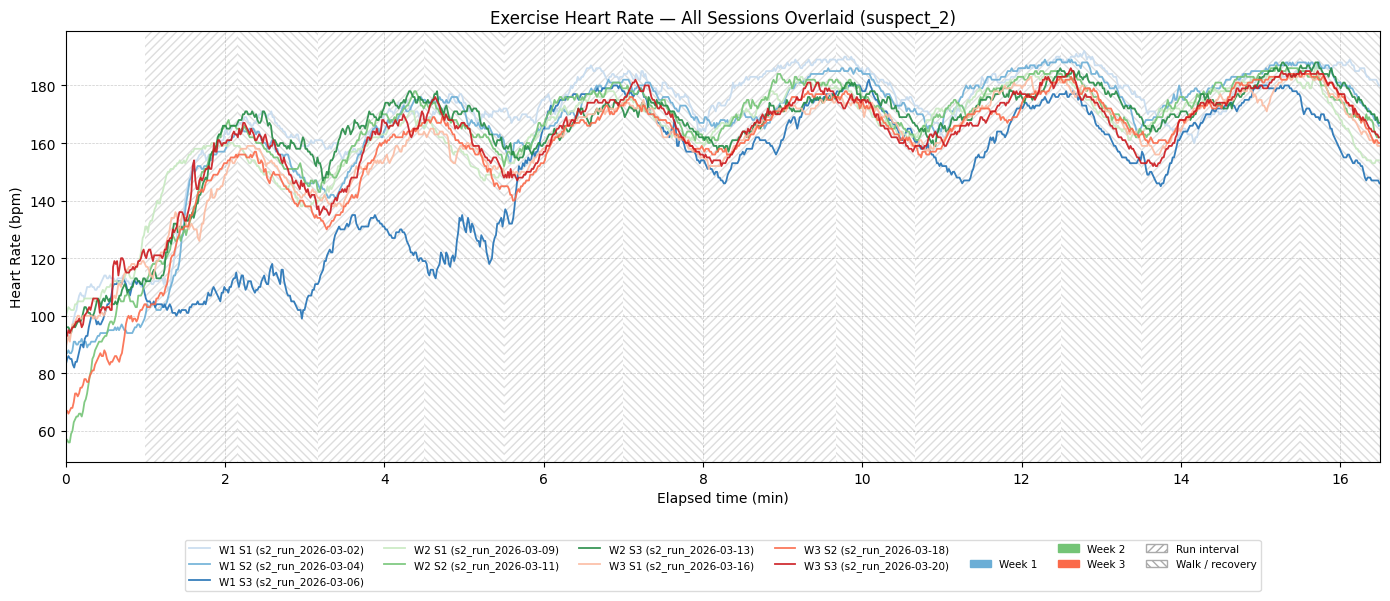

In [3]:
# Suspect 2
plot_hr_all_sessions(
    json_path="../processed/JBM170_HR_Day1-21_P2.json",
    run_start_sec=60,
    time_unit="minutes",
)

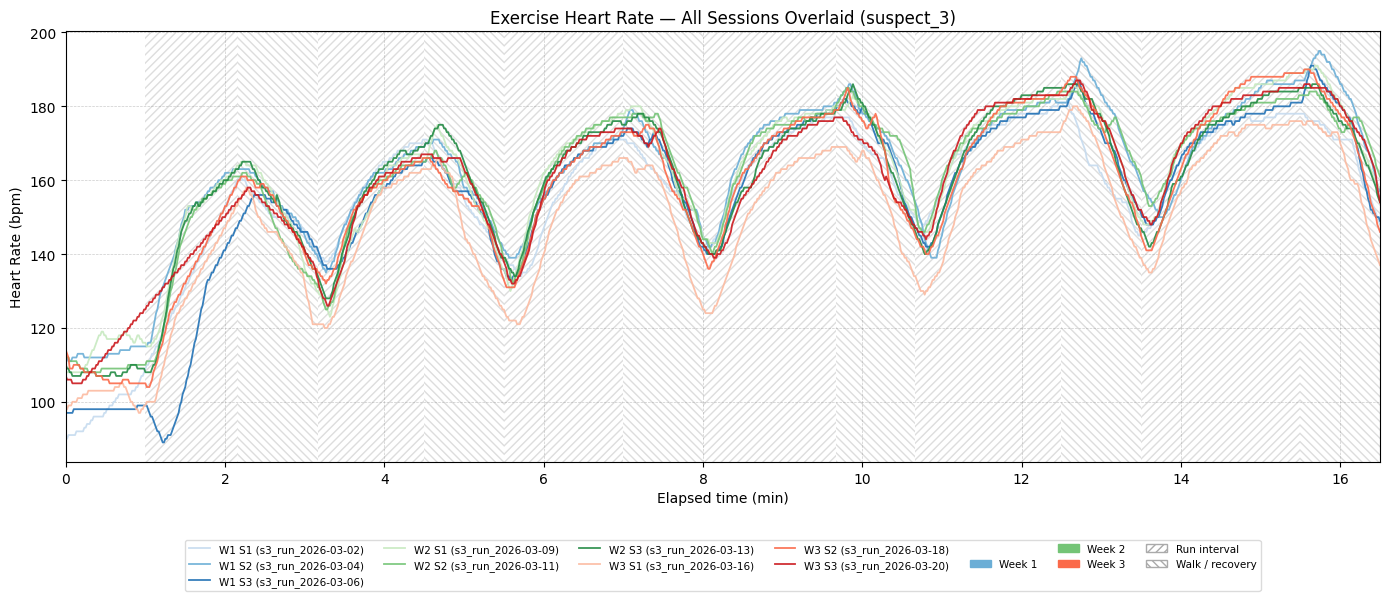

In [4]:
# Suspect 3
plot_hr_all_sessions(
    json_path="../processed/JBM170_HR_Day1-21_P3.json",
    run_start_sec=60,
    time_unit="minutes",
)

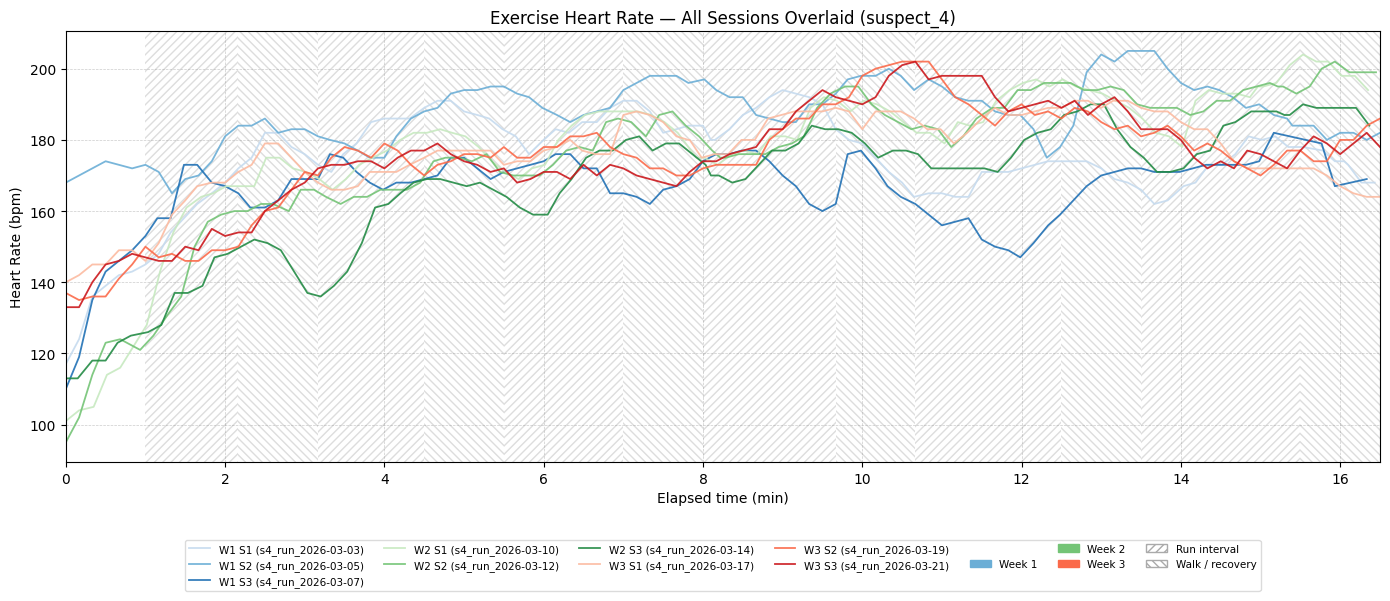

In [5]:
# Suspect 4
plot_hr_all_sessions(
    json_path="../processed/JBM170_HR_Day1-21_P4.json",
    run_start_sec=60,
    time_unit="minutes",
)

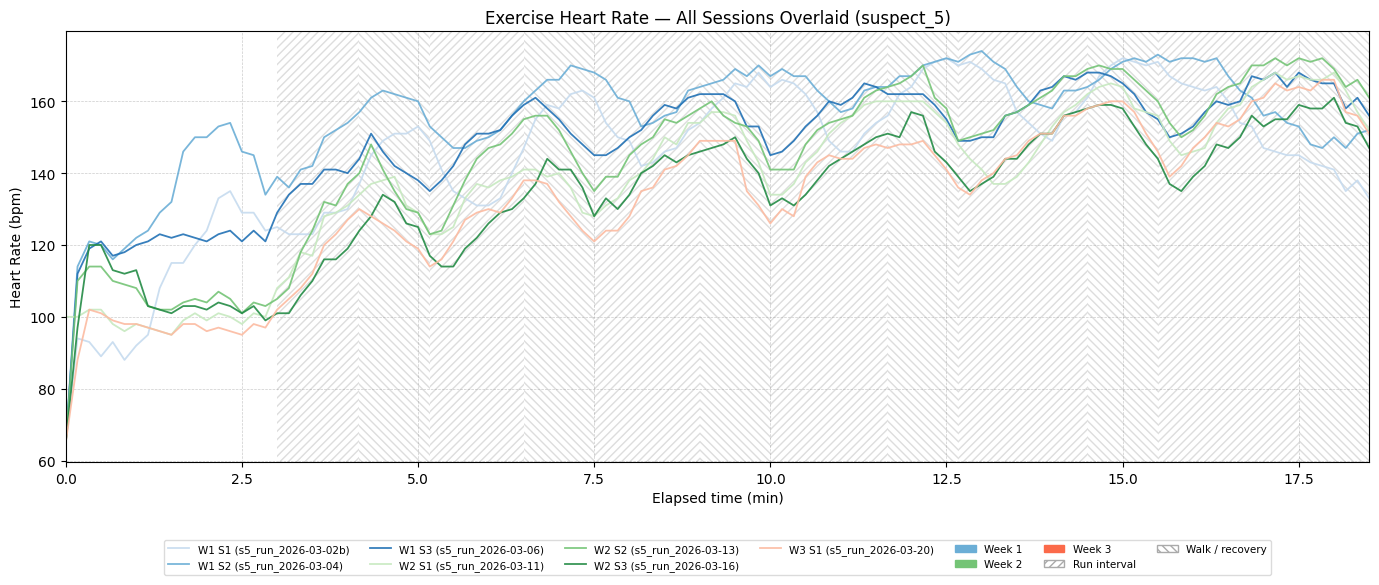

In [6]:
# Suspect 5
plot_hr_all_sessions(
    json_path="../processed/JBM170_HR_Day1-21_P5.json",
    run_start_sec=180,
    time_unit="minutes",
)

**Plot 2: Mean HR per session across all training days**

In [7]:
def compute_mean_hr_per_session(runs: list, run_start_sec: float) -> list:
    """
    For each session, compute mean HR over the protocol window only:
    from run_start_sec to run_start_sec + PROTOCOL_DURATION_SEC.

    Returns a list of dicts with keys: run_id, session_index, mean_hr (or None if no data).
    """
    results = []

    for idx, run in enumerate(runs):
        records = run["per_second_data"]
        if not records:
            results.append({"run_id": run["run_id"], "session_index": idx, "mean_hr": None})
            continue

        t0_abs = datetime.fromisoformat(records[0]["timestamp"])
        protocol_end_sec = run_start_sec + PROTOCOL_DURATION_SEC

        hrs_in_window = []
        for rec in records:
            t_abs = datetime.fromisoformat(rec["timestamp"])
            elapsed = (t_abs - t0_abs).total_seconds()
            if run_start_sec <= elapsed <= protocol_end_sec:
                hrs_in_window.append(rec["heart_rate"])

        mean_hr = np.mean(hrs_in_window) if hrs_in_window else None
        results.append({
            "run_id": run["run_id"],
            "session_index": idx,
            "mean_hr": mean_hr,
        })

    return results


def plot_mean_hr_per_session(
    json_path: str,
    run_start_sec: float,
    figsize: tuple = (9, 5),
    title: str = None,
):
    """
    Plot mean heart rate per session across all training days for one participant.
    Mean is computed over the protocol window only (run_start_sec to run_start_sec + 930s).
    Sessions are coloured by week (week 1=blue, week 2=green, week 3=red), light to dark.
    A linear trendline is fitted across all sessions.

    Parameters
    ----------
    json_path      : path to suspect_#.json
    run_start_sec  : elapsed seconds from recording start to first run interval
    figsize        : figure size tuple
    title          : optional plot title override
    """
    # ------------------------------------------------------------------ load
    with open(json_path, "r") as f:
        data = json.load(f)

    suspect_id = data["suspect_id"]
    runs = data["runs"]

    # -------------------------------------------------------- compute means
    session_results = compute_mean_hr_per_session(runs, run_start_sec)

    session_indices = [r["session_index"] + 1 for r in session_results if r["mean_hr"] is not None]
    mean_hrs        = [r["mean_hr"]         for r in session_results if r["mean_hr"] is not None]
    colors          = get_session_colors(len(runs))
    point_colors    = [colors[r["session_index"]] for r in session_results if r["mean_hr"] is not None]

    # ------------------------------------------------------------------ plot
    fig, ax = plt.subplots(figsize=figsize)

    # Connecting line in neutral grey
    ax.plot(session_indices, mean_hrs, color="#aaaaaa", linewidth=1.2,
            linestyle="--", zorder=1)

    # Linear trendline
    x_arr = np.array(session_indices)
    y_arr = np.array(mean_hrs)
    slope, intercept = np.polyfit(x_arr, y_arr, 1)
    trend_x = np.linspace(x_arr.min(), x_arr.max(), 200)
    trend_y = slope * trend_x + intercept
    direction = "↓" if slope < 0 else "↑"
    ax.plot(
        trend_x, trend_y,
        color="#e07b39",
        linewidth=1,
        alpha=0.6,
        linestyle="-",
        zorder=2,
        label=f"Trend ({direction} {abs(slope):.2f} bpm/session)",
    )

    # Individual session dots coloured by week
    for x, y, c in zip(session_indices, mean_hrs, point_colors):
        ax.scatter(x, y, color=c, s=80, zorder=3, edgecolors="white", linewidths=0.6)

    # Annotate each point with its value
    for x, y in zip(session_indices, mean_hrs):
        ax.annotate(f"{y:.1f}", xy=(x, y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=7.5)

    # Grid
    ax.set_axisbelow(True)
    ax.grid(axis="both", color="grey", linestyle="--", linewidth=0.5, alpha=0.4)

    # x-axis: session number with week label
    ax.set_xticks(range(1, len(runs) + 1))
    ax.set_xticklabels([
        f"S{i}\n(W{((i-1)//3)+1})" for i in range(1, len(runs) + 1)
    ], fontsize=8)

    # Legend — trendline + week colours, placed below plot
    week_patches = [
        mpatches.Patch(color=WEEK_PALETTES[w][1], label=f"Week {w}") for w in [1, 2, 3]
    ]
    trend_handle = mpatches.Patch(
        color="#e07b39",
        label=f"Trend ({direction} {abs(slope):.2f} bpm/session)"
    )

    ax.legend(
        handles=week_patches + [trend_handle],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=4,
        fontsize=8,
        framealpha=0.7,
        borderaxespad=0,
    )

    ax.set_xlabel("Session")
    ax.set_ylabel("Mean Heart Rate (bpm)")
    ax.set_title(title or f"Mean HR per Session — Protocol Window Only ({suspect_id})")
    ax.set_xlim(0.5, len(runs) + 0.5)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.20)
    plt.show()

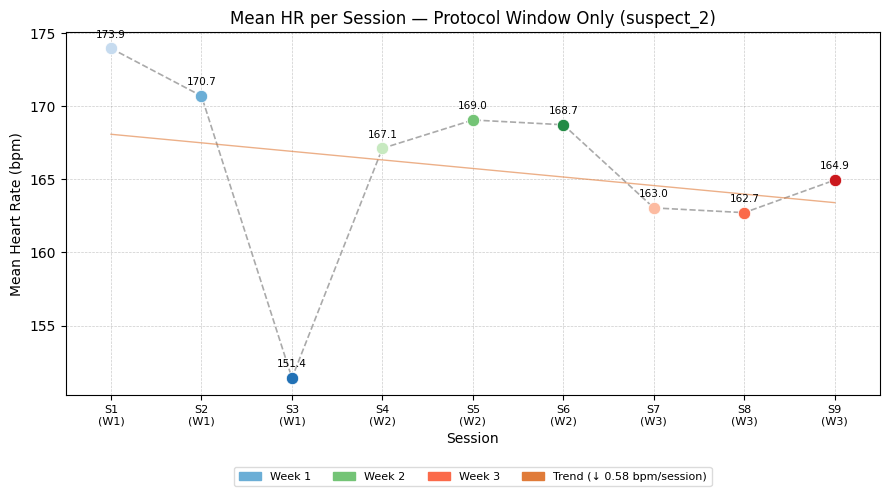

In [8]:
# Suspect 2
plot_mean_hr_per_session(
    json_path="../processed/JBM170_HR_Day1-21_P2.json",
    run_start_sec=60,
)

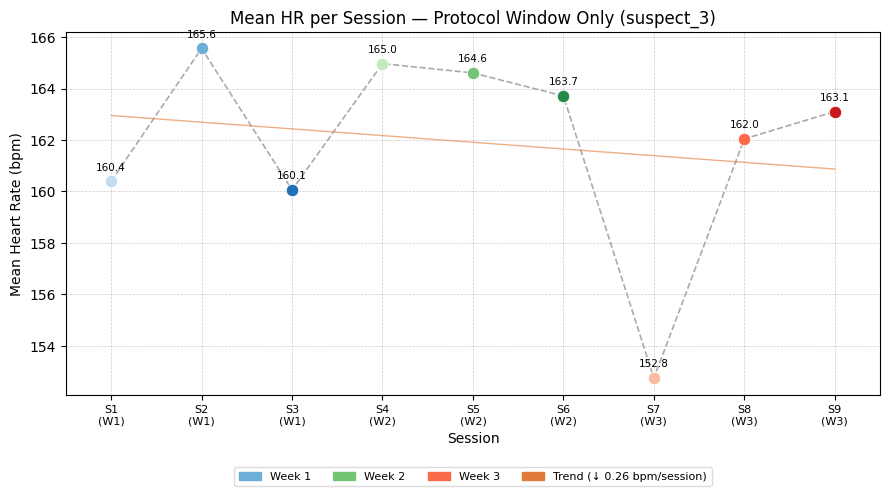

In [9]:
# Suspect 3
plot_mean_hr_per_session(
    json_path="../processed/JBM170_HR_Day1-21_P3.json",
    run_start_sec=60,
)

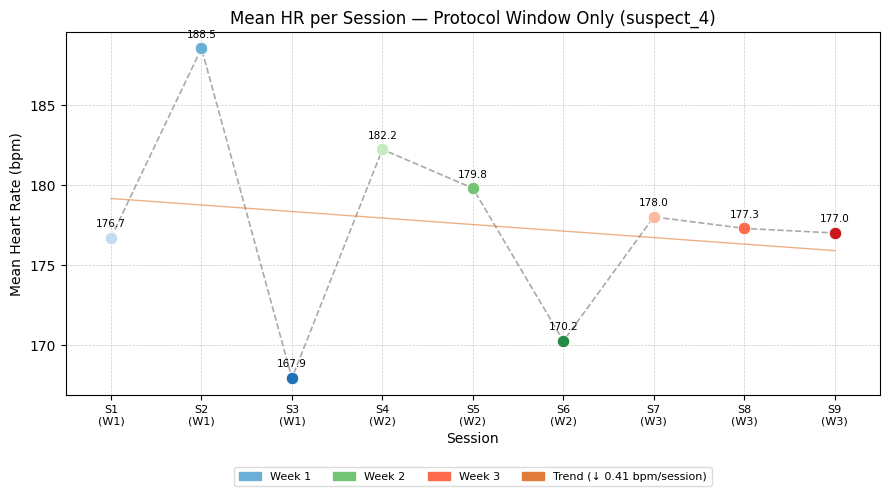

In [10]:
# Suspect 4
plot_mean_hr_per_session(
    json_path="../processed/JBM170_HR_Day1-21_P4.json",
    run_start_sec=60,
)

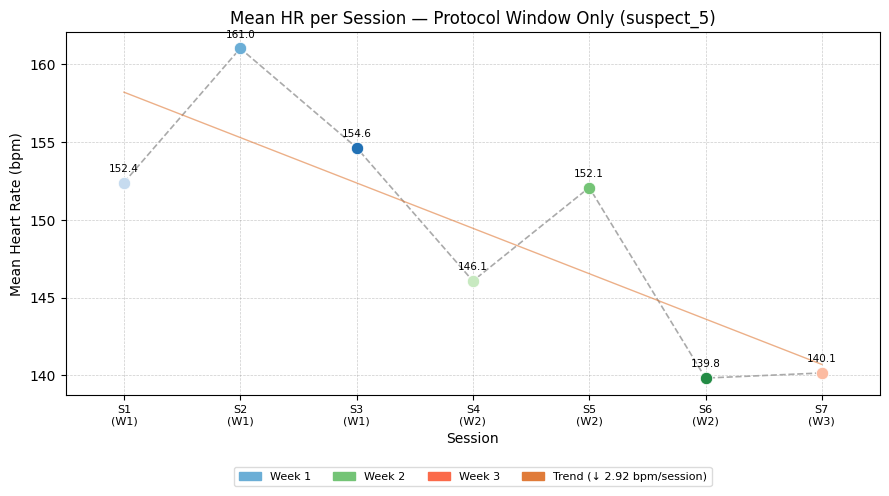

In [11]:
# Suspect 5
plot_mean_hr_per_session(
    json_path="../processed/JBM170_HR_Day1-21_P5.json",
    run_start_sec=180,
)

**Plot 3: Average HR rise rate per session across all training days**

The rise rate for each run interval is averaged across all 6 intervals per session. The shaded band shows the min-max range of rise rates within each session.

In [12]:
def plot_avg_rise_rate(
    json_path: str,
    run_start_sec: float,
    edge_window_sec: int = 5,
    figsize: tuple = (9, 5),
    title: str = None,
):
    suspect_id, runs = load_suspect(json_path)
    data = compute_hr_rise_rate(runs, run_start_sec, edge_window_sec)
    colors = get_session_colors(len(runs))

    session_nums, avg_vals, min_vals, max_vals, pt_colors = [], [], [], [], []

    for idx in range(len(runs)):
        vals = [data[k][idx] for k in sorted(data.keys()) if data[k][idx] is not None]
        if not vals:
            continue
        session_nums.append(idx + 1)
        avg_vals.append(np.mean(vals))
        min_vals.append(np.min(vals))
        max_vals.append(np.max(vals))
        pt_colors.append(colors[idx])

    session_nums = np.array(session_nums)
    avg_vals = np.array(avg_vals)
    min_vals = np.array(min_vals)
    max_vals = np.array(max_vals)

    fig, ax = plt.subplots(figsize=figsize)
    _draw_grid(ax)

    band_label = "Min\u2013Max range (6 intervals)"
    ax.fill_between(session_nums, min_vals, max_vals,
                    color="#e07b39", alpha=0.15, label=band_label)

    ax.plot(session_nums, avg_vals, color="#aaaaaa", linewidth=1.2, linestyle="--", zorder=1)

    slope, intercept = np.polyfit(session_nums, avg_vals, 1)
    trend_x = np.linspace(session_nums.min(), session_nums.max(), 200)
    trend_y = slope * trend_x + intercept
    direction = "\u2191" if slope > 0 else "\u2193"
    ax.plot(trend_x, trend_y, color="#e07b39", linewidth=2, linestyle="-", zorder=2,
            label=f"Trend ({direction} {abs(slope):.2f} bpm/min/session)")

    for x, y, c in zip(session_nums, avg_vals, pt_colors):
        ax.scatter(x, y, color=c, s=80, zorder=3, edgecolors="white", linewidths=0.6)

    for x, y in zip(session_nums, avg_vals):
        ax.annotate(f"{y:.1f}", xy=(x, y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=7.5)

    ax.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle="-", zorder=1)

    _add_session_xticks(ax, len(runs))

    week_patches = [
        mpatches.Patch(color=WEEK_PALETTES[w][1], label=f"Week {w}") for w in [1, 2, 3]
    ]
    trend_patch = mpatches.Patch(color="#e07b39",
                                 label=f"Trend ({direction} {abs(slope):.2f} bpm/min/session)")
    band_patch = mpatches.Patch(color="#e07b39", alpha=0.3, label=band_label)

    ax.legend(
        handles=week_patches + [trend_patch, band_patch],
        loc="upper center", bbox_to_anchor=(0.5, -0.20),
        ncol=5, fontsize=8, framealpha=0.7, borderaxespad=0,
    )

    ax.set_xlabel("Session")
    ax.set_ylabel("Avg HR rise rate (bpm/min)")
    ax.set_title(title or f"Avg HR Rise Rate per Session ({suspect_id})")
    ax.set_xlim(0.5, len(runs) + 0.5)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.22)
    plt.show()

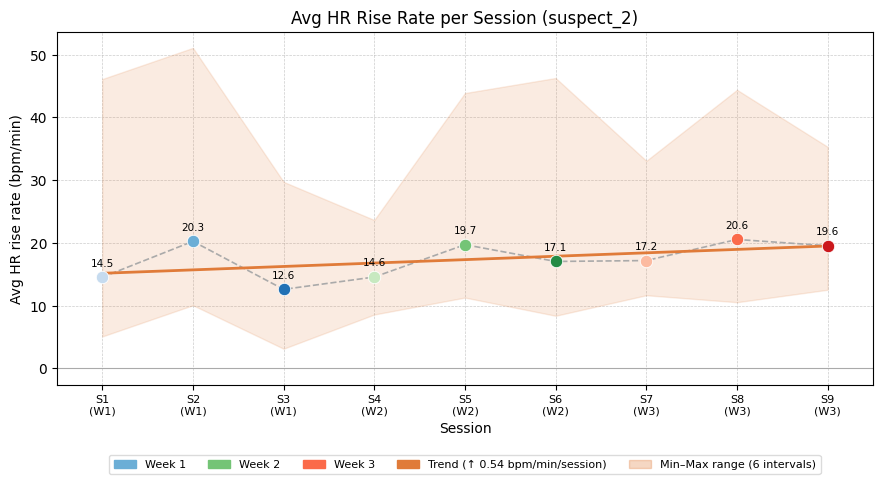

In [13]:
# Suspect 2
plot_avg_rise_rate(json_path="../processed/JBM170_HR_Day1-21_P2.json", run_start_sec=60)

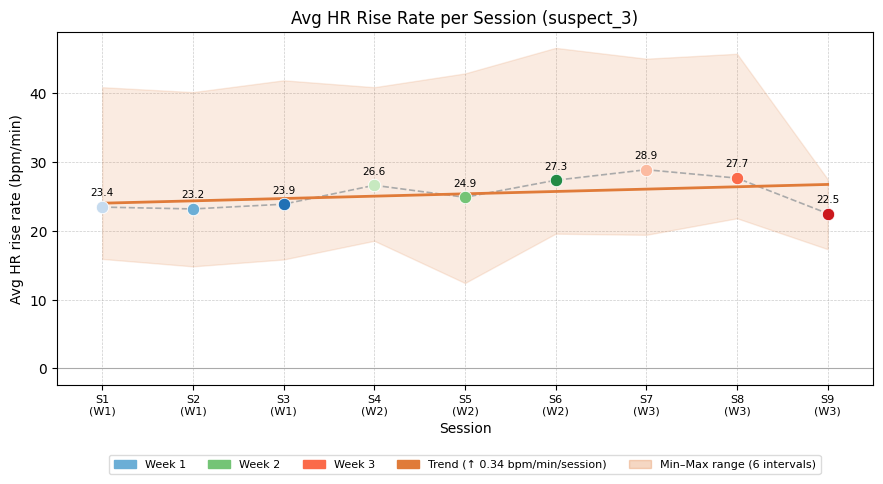

In [14]:
# Suspect 3
plot_avg_rise_rate(json_path="../processed/JBM170_HR_Day1-21_P3.json", run_start_sec=60)

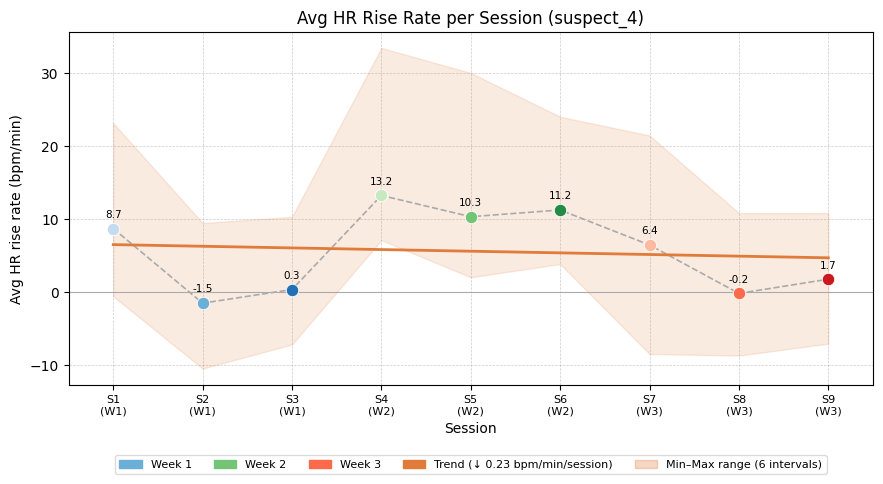

In [15]:
# Suspect 4
plot_avg_rise_rate(json_path="../processed/JBM170_HR_Day1-21_P4.json", run_start_sec=60)

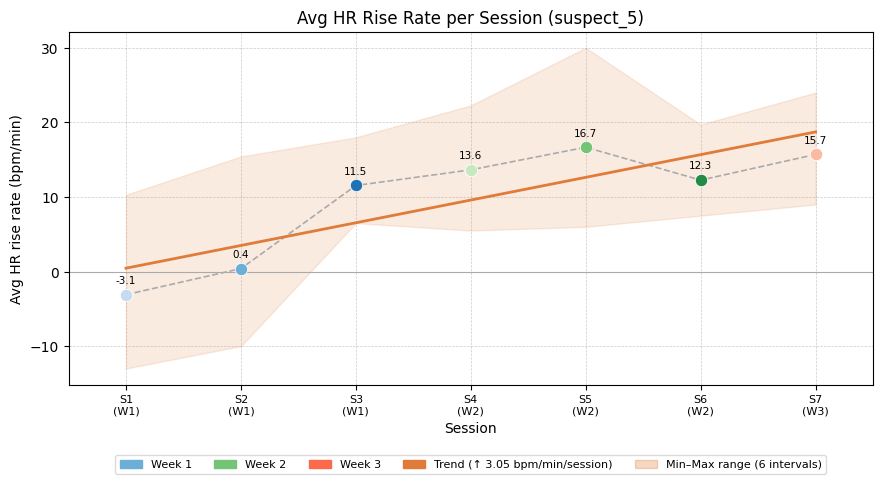

In [16]:
# Suspect 5
plot_avg_rise_rate(json_path="../processed/JBM170_HR_Day1-21_P5.json", run_start_sec=180)

**Plot 4: Average HR drop rate per session across all training days**

The drop rate for each walk interval is averaged across all 6 intervals per session. Positive values mean HR is decreasing (good recovery). The shaded band shows the min-max range within each session.

In [17]:
def plot_avg_drop_rate(
    json_path: str,
    run_start_sec: float,
    edge_window_sec: int = 5,
    figsize: tuple = (9, 5),
    title: str = None,
):
    suspect_id, runs = load_suspect(json_path)
    data = compute_hr_drop_rate(runs, run_start_sec, edge_window_sec)
    colors = get_session_colors(len(runs))

    session_nums, avg_vals, min_vals, max_vals, pt_colors = [], [], [], [], []

    for idx in range(len(runs)):
        vals = [data[k][idx] for k in sorted(data.keys()) if data[k][idx] is not None]
        if not vals:
            continue
        session_nums.append(idx + 1)
        avg_vals.append(np.mean(vals))
        min_vals.append(np.min(vals))
        max_vals.append(np.max(vals))
        pt_colors.append(colors[idx])

    session_nums = np.array(session_nums)
    avg_vals = np.array(avg_vals)
    min_vals = np.array(min_vals)
    max_vals = np.array(max_vals)

    fig, ax = plt.subplots(figsize=figsize)
    _draw_grid(ax)

    band_label = "Min\u2013Max range (6 intervals)"
    ax.fill_between(session_nums, min_vals, max_vals,
                    color="#e07b39", alpha=0.15, label=band_label)

    ax.plot(session_nums, avg_vals, color="#aaaaaa", linewidth=1.2, linestyle="--", zorder=1)

    slope, intercept = np.polyfit(session_nums, avg_vals, 1)
    trend_x = np.linspace(session_nums.min(), session_nums.max(), 200)
    trend_y = slope * trend_x + intercept
    direction = "\u2191" if slope > 0 else "\u2193"
    ax.plot(trend_x, trend_y, color="#e07b39", linewidth=2, linestyle="-", zorder=2,
            label=f"Trend ({direction} {abs(slope):.2f} bpm/min/session)")

    for x, y, c in zip(session_nums, avg_vals, pt_colors):
        ax.scatter(x, y, color=c, s=80, zorder=3, edgecolors="white", linewidths=0.6)

    for x, y in zip(session_nums, avg_vals):
        ax.annotate(f"{y:.1f}", xy=(x, y), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=7.5)

    ax.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle="-", zorder=1)

    _add_session_xticks(ax, len(runs))

    week_patches = [
        mpatches.Patch(color=WEEK_PALETTES[w][1], label=f"Week {w}") for w in [1, 2, 3]
    ]
    trend_patch = mpatches.Patch(color="#e07b39",
                                 label=f"Trend ({direction} {abs(slope):.2f} bpm/min/session)")
    band_patch = mpatches.Patch(color="#e07b39", alpha=0.3, label=band_label)

    ax.legend(
        handles=week_patches + [trend_patch, band_patch],
        loc="upper center", bbox_to_anchor=(0.5, -0.20),
        ncol=5, fontsize=8, framealpha=0.7, borderaxespad=0,
    )

    ax.set_xlabel("Session")
    ax.set_ylabel("Avg HR drop rate (bpm/min)")
    ax.set_title(title or f"Avg HR Drop Rate per Session ({suspect_id})")
    ax.set_xlim(0.5, len(runs) + 0.5)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.22)
    plt.show()

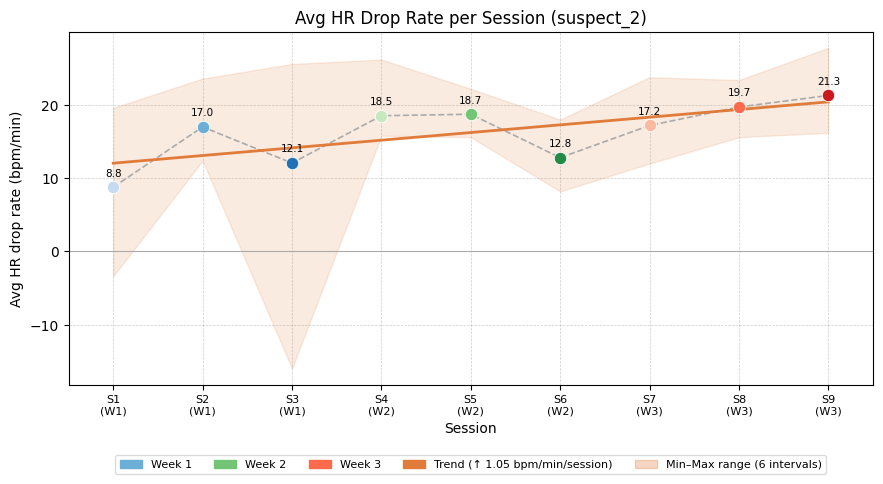

In [18]:
# Suspect 2
plot_avg_drop_rate(json_path="../processed/JBM170_HR_Day1-21_P2.json", run_start_sec=60)

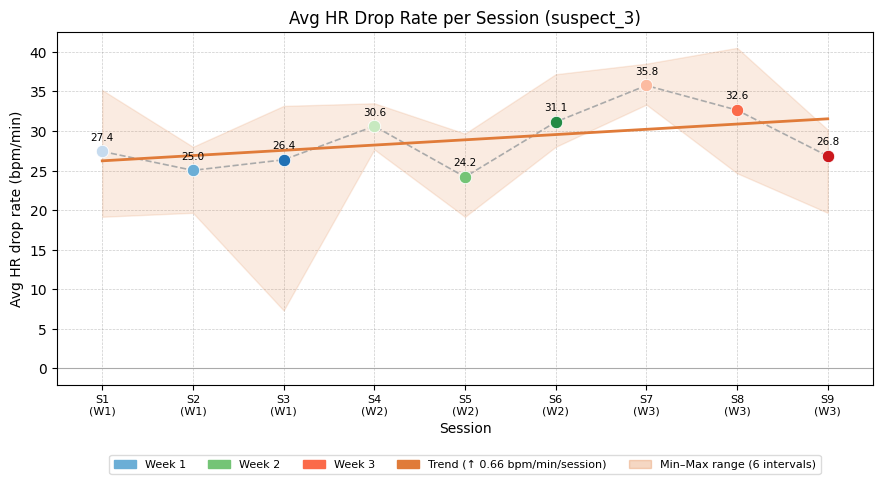

In [19]:
# Suspect 3
plot_avg_drop_rate(json_path="../processed/JBM170_HR_Day1-21_P3.json", run_start_sec=60)

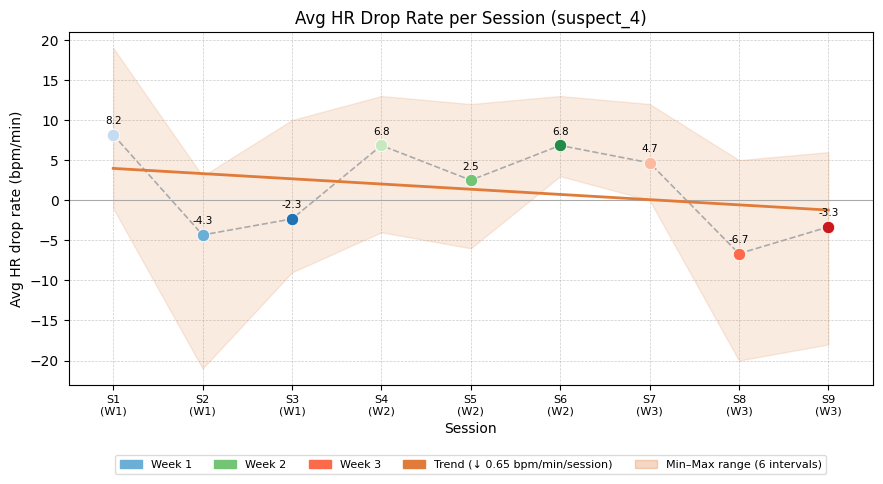

In [20]:
# Suspect 4
plot_avg_drop_rate(json_path="../processed/JBM170_HR_Day1-21_P4.json", run_start_sec=60)

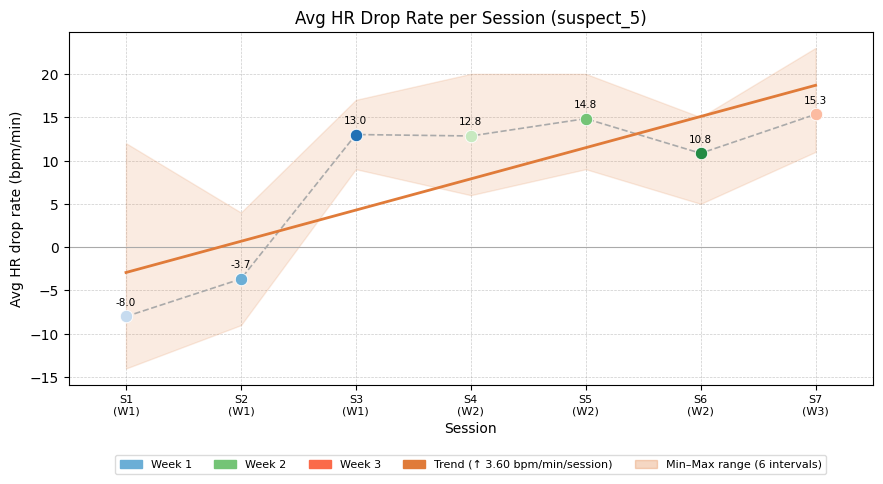

In [21]:
# Suspect 5
plot_avg_drop_rate(json_path="../processed/JBM170_HR_Day1-21_P5.json", run_start_sec=180)